### load dataset

In [10]:
from scripts.session_loader import *
from scripts.dataset_loader import *    

In [11]:
dataset = load_dataset("resolution_study_data")

### load a session

In [12]:
session_key = dataset["session_id"][0]
session = load_session(session_key)

In [25]:
session_key

'20251219_1736'

### normalize data per channel

In [13]:
import matplotlib.pyplot as plt
import numpy as np

In [14]:
def normalize_channel(data):
    med = np.median(data)
    mad = np.median(np.abs(data - med))
    scale = mad * 1.4826 + 1e-12  # approximate stddev
    return (data - med) / scale

In [23]:
def plot_channel(data, channel_name):
    colormap = {
        "CH1": "red",
        "CH2": "green",
        "CH3": "blue",
        "CH4": "orange",
        "CH5": "purple",
        "Force_X": "brown",
        "Force_Z": "gray",
    }
    norm_data = normalize_channel(data)
    plt.figure(figsize=(15, 3))
    color = colormap.get(channel_name, "tab:blue")
    plt.plot(norm_data, label=channel_name, color=color)
    plt.title(f"Normalized Signal for {channel_name}")
    plt.xlabel("Sample Index")
    plt.ylabel("Normalized Amplitude")
    plt.legend()

In [16]:
chs = session.data.columns
norm_data = []
for ch in chs:
    data = session.data[ch].to_numpy()
    norm_data.append(normalize_channel(data))

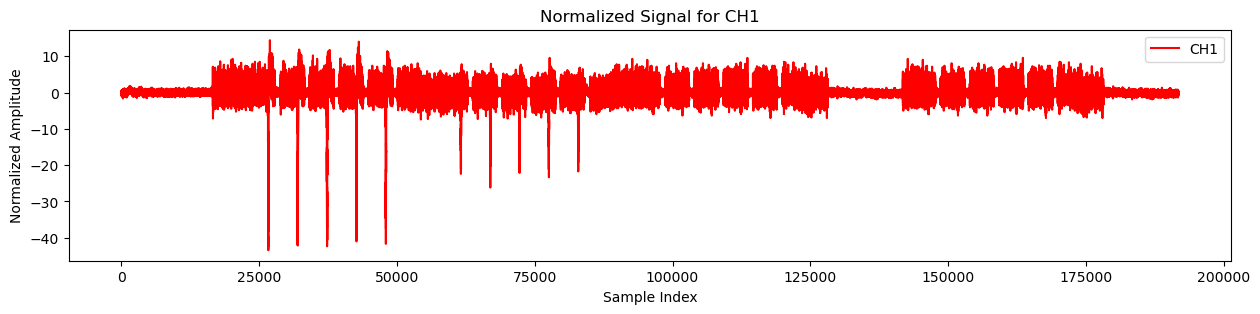

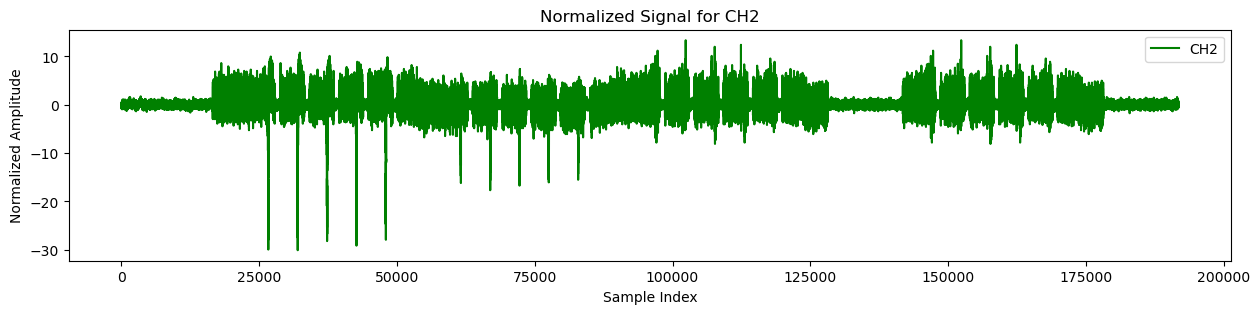

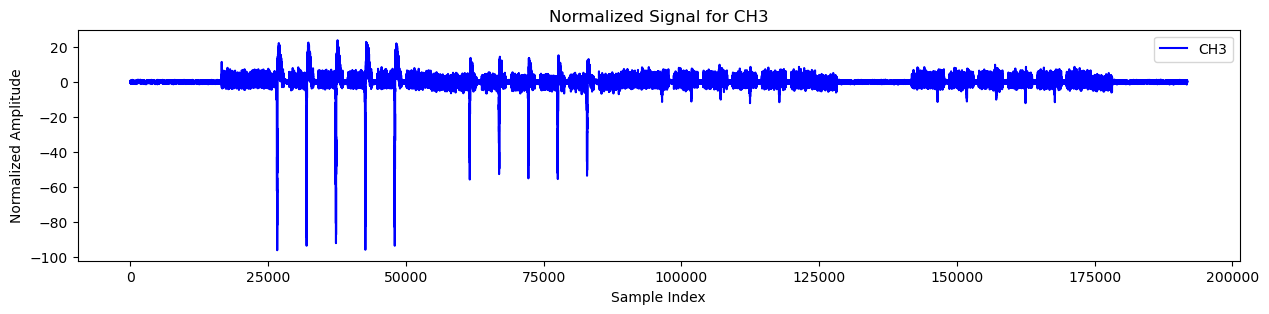

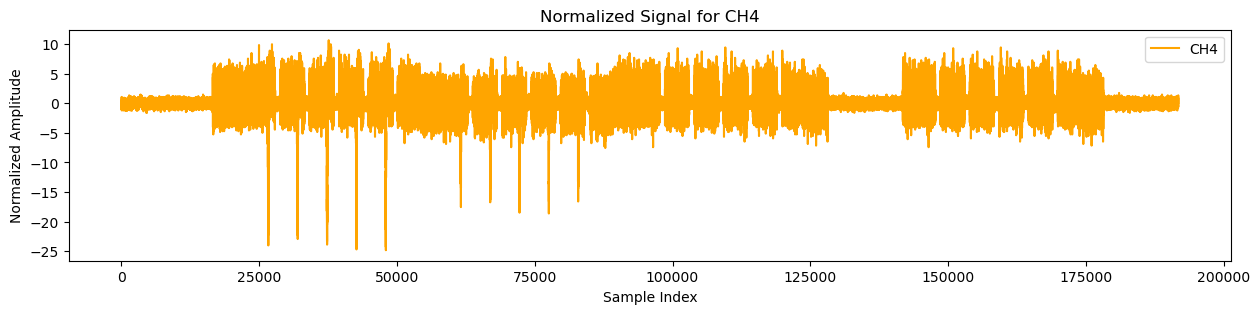

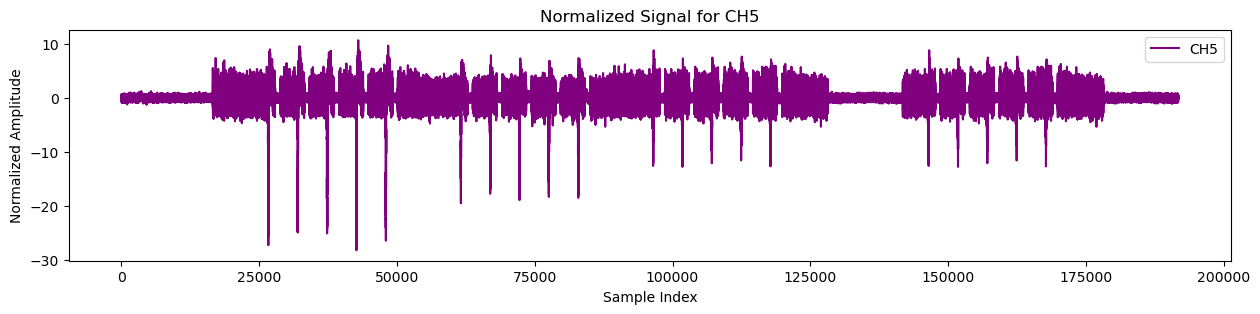

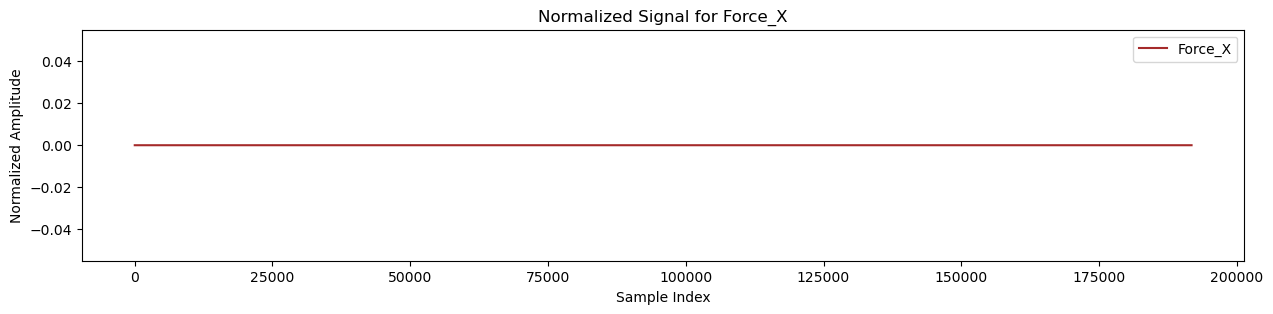

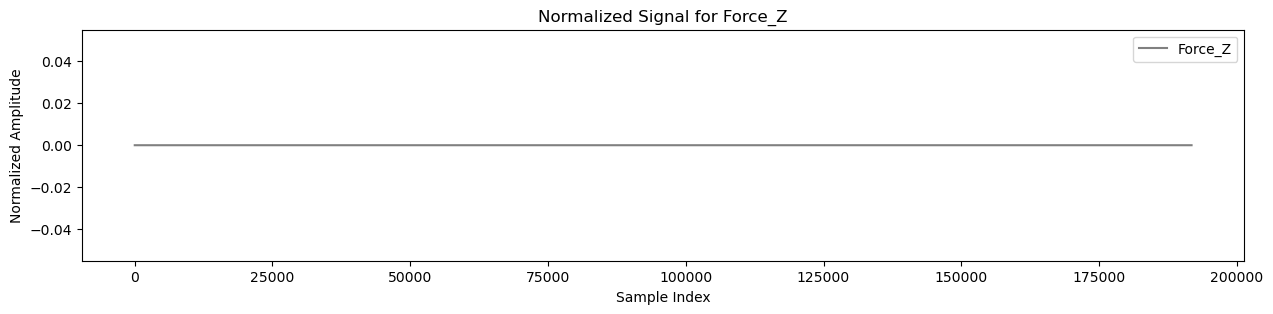

In [24]:
# f, ax = plt.subplots(len(chs), 1, figsize=(15, 5))
for i, ch in enumerate(chs):
    plot_channel(session.data[ch], ch)

# Todo: given data plot traces

In [1]:
datapath = "30_wDS_move_20251219_1736.csv"

In [2]:
import matplotlib.pyplot as plt
import csv
import pandas as pd

In [3]:
data = pd.read_csv(datapath)

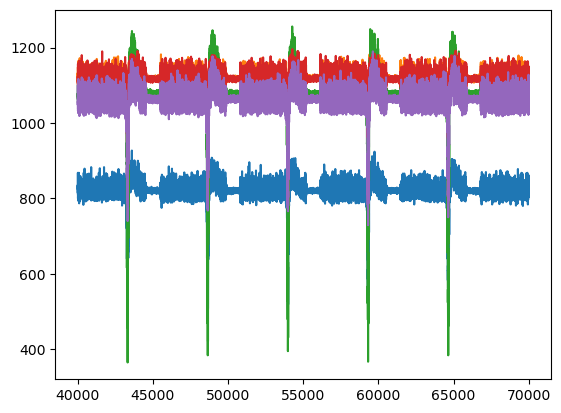

In [4]:
ch_names = ["CH%d"%i for i in range(1,6)]
for ch_name in ch_names:
    plt.plot(data[ch_name][40000:70000])

In [5]:
import scipy.signal as signal

In [6]:
fs = 16666.666666666664

In [7]:
data_ch = data["CH1"].to_numpy()

In [10]:
x_filt = data_ch.copy()
for f0 in [60, 120, 180]:
    b, a = signal.iirnotch(f0, Q=30, fs=fs)
    x_filt = signal.filtfilt(b, a, x_filt)

In [11]:
f, Pxx = signal.welch(data_ch, fs, nperseg=2048)
f2, Pxx2 = signal.welch(x_filt, fs, nperseg=2048)

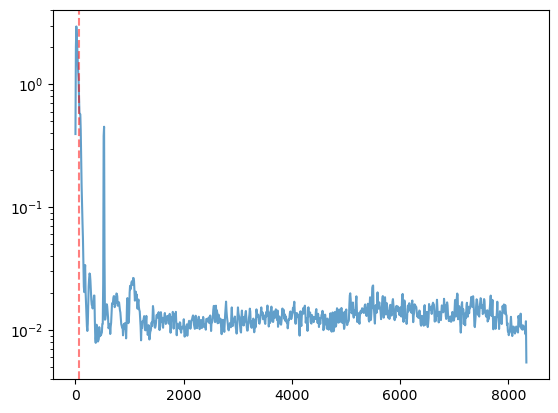

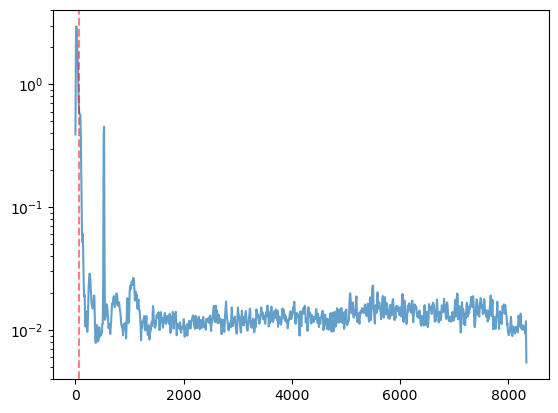

In [16]:
plt.semilogy(f, Pxx, label="raw", alpha=0.7)
plt.axvline(60, color='r', linestyle='--', alpha=0.5)
plt.figure()
plt.semilogy(f2, Pxx2, label="notch filtered", alpha=0.7)
plt.axvline(60, color='r', linestyle='--', alpha=0.5)
